# Perhitungan Volume Kedua Lambung Kapal

**Mata Kuliah:** Analisis Numerik  
**Topik:** Perhitungan Volume  
**Nama:** Oline Ola Fadhillah 
**NPM:** 25083010028
**Kelas:** A

## 1. Deskripsi Permasalahan

Tugas ini menghitung **volume kedua lambung** kapal katamaran berdasarkan gambar tampak atas dan tampak samping yang diberi grid hijau putus-putus.

Ketentuan dari soal:

- Satu **dash-kosong** (satu garis hijau putus-putus + satu celah kosong) berukuran 5 + 5 cm = 10 cm.
- Lantai kapal dianggap datar (tidak ada keel), sehingga tampak depan lambung seluruhnya berbentuk persegi panjang.
- Volume *reserve buoyancy* tidak dihitung.
- Volume dihitung untuk **kedua** lambung.

Pada langkah pertama ini, gambar kapal dibaca dan ditampilkan terlebih dahulu sebagai dasar untuk seluruh pengukuran berikutnya.

Ukuran gambar (lebar x tinggi): (927, 643) piksel


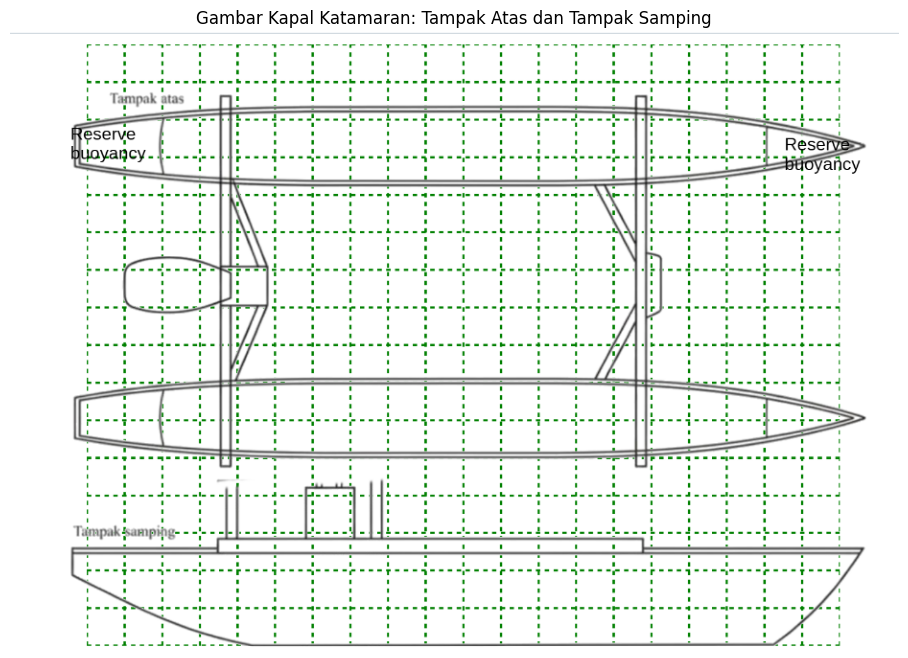

In [1]:
import matplotlib.pyplot as plt
from PIL import Image

# Membaca gambar kapal (satu folder dengan notebook ini)
gambar = Image.open("perahu_page1.png").convert("RGB")

print("Ukuran gambar (lebar x tinggi):", gambar.size, "piksel")

# Menampilkan gambar kapal
plt.figure(figsize=(14, 8))
plt.imshow(gambar)
plt.title("Gambar Kapal Katamaran: Tampak Atas dan Tampak Samping")
plt.axis("off")
plt.show()

### Interpretasi

Gambar berhasil dibaca dan terdiri dari dua bagian:

- **Tampak atas**: memperlihatkan kedua lambung (lambung atas dan lambung bawah). Bagian ini akan dipakai untuk mengukur *panjang* dan *lebar* lambung. Area *reserve buoyancy* berada di kedua ujung lambung dan tidak ikut dihitung.
- **Tampak samping**: memperlihatkan bentuk lambung dari samping. Bagian ini akan dipakai untuk mengukur *tinggi* lambung.

Seluruh gambar tertutup grid hijau putus-putus yang akan menjadi acuan skala pada langkah berikutnya.

## 2. Menentukan Skala Gambar

Soal hanya memberi tahu bahwa **satu dash-kosong = 5 + 5 cm = 10 cm**. Satu dash-kosong adalah satu garis hijau pendek ditambah satu celah kosong setelahnya, **bukan** jarak antar-garis grid. Karena itu, skala gambar harus dicari dari panjang satu dash-kosong dalam piksel:

$$
\text{skala (piksel/meter)} = \frac{\text{panjang 1 dash-kosong (piksel)}}{0{,}1\ \text{m}}
$$

Langkah yang dilakukan:
1. Mendeteksi piksel berwarna hijau (garis grid).
2. Menentukan posisi garis grid horizontal dan vertikal.
3. Mengukur panjang satu dash-kosong (dash + celah) dalam piksel.
4. Menghitung skala piksel per meter dan ukuran satu kotak grid.
5. Memvalidasi hasil deteksi dengan menampilkan garis grid beserta koordinat x dan y.

1 dash-kosong = 10 cm = 0.1 m
Jumlah garis horizontal : 17
Jumlah garis vertikal   : 21
Jarak antar garis horizontal (px): [39.  39.  39.  39.5 39.  39.5 39.  39.  39.5 39.5 39.  39.5 39.  39.
 39.5 38.5]
Jarak antar garis vertikal (px)  : [38.5 39.5 39.  39.5 39.  39.  39.5 39.  39.5 39.5 39.  39.5 38.5 39.5
 39.5 39.  39.5 39.  39.5 38.5]

1 dash-kosong arah X : 9.16 px (dari 1149 dash)
1 dash-kosong arah Y : 9.12 px (dari 1119 dash)
Rata-rata            : 9.14 px = 0.1 m
Skala gambar         : 91.40 px/m
1 kotak grid arah X  : 39.25 px = 0.429 m = 4.29 dash-kosong
1 kotak grid arah Y  : 39.00 px = 0.427 m = 4.27 dash-kosong


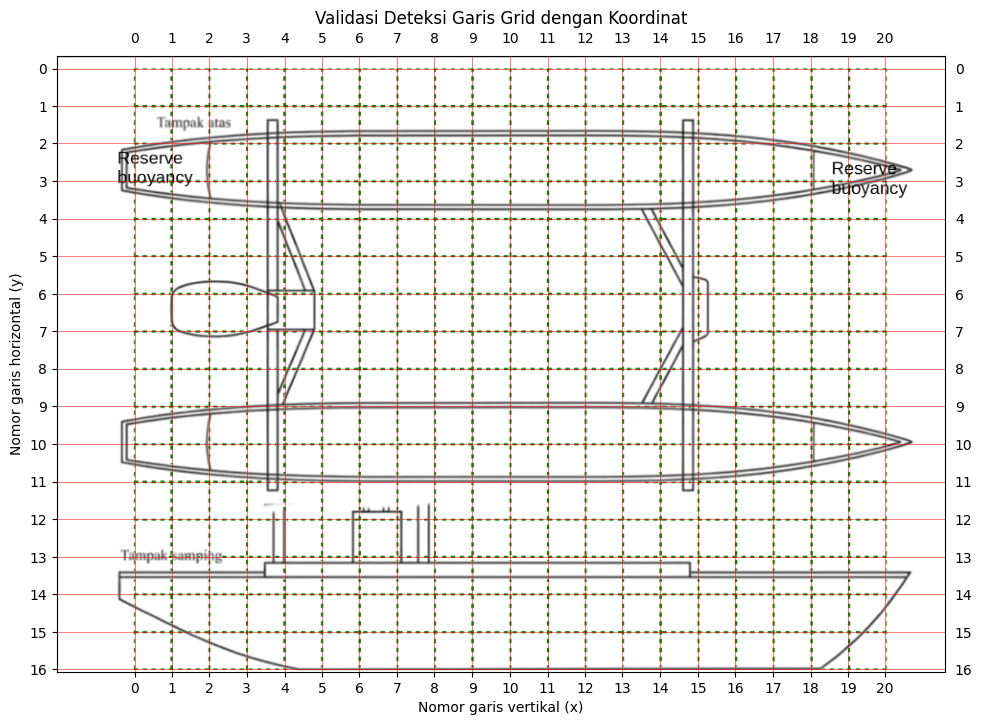

In [5]:
import numpy as np

# Ukuran satu dash-kosong menurut soal: 5 cm garis + 5 cm celah
dash_kosong_cm = 5 + 5
meter_per_dash = dash_kosong_cm / 100

print(f"1 dash-kosong = {dash_kosong_cm} cm = {meter_per_dash} m")

# Mendeteksi piksel hijau (garis grid): nilai G jauh lebih besar dari R dan B
data = np.array(gambar).astype(int)
R, G, B = data[:, :, 0], data[:, :, 1], data[:, :, 2]
mask_hijau = (G - np.maximum(R, B)) > 40

# Jumlah piksel hijau pada setiap baris dan kolom
jumlah_hijau_baris = mask_hijau.sum(axis=1)
jumlah_hijau_kolom = mask_hijau.sum(axis=0)

# Baris/kolom dengan piksel hijau yang banyak dianggap garis grid
kandidat_baris = np.where(jumlah_hijau_baris > 0.25 * jumlah_hijau_baris.max())[0]
kandidat_kolom = np.where(jumlah_hijau_kolom > 0.25 * jumlah_hijau_kolom.max())[0]


# Mengelompokkan posisi piksel yang berdekatan menjadi satu garis grid
def kelompokkan_garis(posisi, jarak_maks=3):
    kelompok = []
    sementara = [posisi[0]]

    for i in range(1, len(posisi)):
        if posisi[i] - posisi[i - 1] <= jarak_maks:
            sementara.append(posisi[i])
        else:
            kelompok.append(sementara)
            sementara = [posisi[i]]

    kelompok.append(sementara)

    # Titik tengah setiap kelompok = posisi garis
    return np.array([np.mean(k) for k in kelompok])


garis_horizontal = kelompokkan_garis(kandidat_baris)
garis_vertikal = kelompokkan_garis(kandidat_kolom)

jarak_horizontal = np.diff(garis_horizontal)
jarak_vertikal = np.diff(garis_vertikal)

print("Jumlah garis horizontal :", len(garis_horizontal))
print("Jumlah garis vertikal   :", len(garis_vertikal))
print("Jarak antar garis horizontal (px):", np.round(jarak_horizontal, 1))
print("Jarak antar garis vertikal (px)  :", np.round(jarak_vertikal, 1))


# Mengukur panjang satu dash-kosong (dash + celah) dalam piksel:
# awal setiap dash = piksel hijau yang berubah dari False ke True
def periode_dash(mask, posisi_garis, arah):
    semua = []

    for p in posisi_garis:
        p = int(round(p))

        if arah == "vertikal":      # garis vertikal -> dash berjalan sepanjang sumbu y
            profil = mask[:, max(p - 1, 0):p + 2].any(axis=1)
        else:                       # garis horizontal -> dash berjalan sepanjang sumbu x
            profil = mask[max(p - 1, 0):p + 2, :].any(axis=0)

        awal = np.where(profil[1:] & ~profil[:-1])[0] + 1
        semua.extend(np.diff(awal))

    semua = np.array(semua)

    # Buang selisih yang menyimpang jauh (misalnya di titik pertemuan garis)
    pusat = np.median(semua)
    bersih = semua[np.abs(semua - pusat) < 0.2 * pusat]

    return bersih.mean(), len(bersih)


pixel_per_dash_x, n_x = periode_dash(mask_hijau, garis_horizontal, "horizontal")
pixel_per_dash_y, n_y = periode_dash(mask_hijau, garis_vertikal, "vertikal")
pixel_per_dash = (pixel_per_dash_x + pixel_per_dash_y) / 2

# Skala gambar
pixel_per_meter = pixel_per_dash / meter_per_dash
meter_per_pixel = 1 / pixel_per_meter

# Ukuran satu kotak grid
pixel_per_kotak_x = np.median(jarak_vertikal)
pixel_per_kotak_y = np.median(jarak_horizontal)

print(f"\n1 dash-kosong arah X : {pixel_per_dash_x:.2f} px (dari {n_x} dash)")
print(f"1 dash-kosong arah Y : {pixel_per_dash_y:.2f} px (dari {n_y} dash)")
print(f"Rata-rata            : {pixel_per_dash:.2f} px = {meter_per_dash} m")
print(f"Skala gambar         : {pixel_per_meter:.2f} px/m")
print(f"1 kotak grid arah X  : {pixel_per_kotak_x:.2f} px = {pixel_per_kotak_x * meter_per_pixel:.3f} m "
      f"= {pixel_per_kotak_x / pixel_per_dash:.2f} dash-kosong")
print(f"1 kotak grid arah Y  : {pixel_per_kotak_y:.2f} px = {pixel_per_kotak_y * meter_per_pixel:.3f} m "
      f"= {pixel_per_kotak_y / pixel_per_dash:.2f} dash-kosong")


# Validasi: garis grid yang terdeteksi digambar di atas gambar asli, lengkap dengan nomor garis
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(gambar)

for x in garis_vertikal:
    ax.axvline(x, color="red", linewidth=0.6, alpha=0.6)
for y in garis_horizontal:
    ax.axhline(y, color="red", linewidth=0.6, alpha=0.6)

# Koordinat = nomor garis grid (dimulai dari 0), tick tepat pada garis grid
ax.set_xticks(garis_vertikal)
ax.set_xticklabels(range(len(garis_vertikal)))
ax.set_yticks(garis_horizontal)
ax.set_yticklabels(range(len(garis_horizontal)))
ax.tick_params(labeltop=True, labelright=True)

ax.set_xlabel("Nomor garis vertikal (x)")
ax.set_ylabel("Nomor garis horizontal (y)")
ax.set_title("Validasi Deteksi Garis Grid dengan Koordinat")
plt.show()

### Interpretasi

Deteksi menemukan **21 garis vertikal** (bernomor 0 sampai 20) dan **17 garis horizontal** (bernomor 0 sampai 16), sehingga grid terdiri dari 20 × 16 kotak. Jarak antar-garisnya hampir seragam, jadi gambar tidak miring atau terdistorsi dan satu skala bisa dipakai untuk seluruh gambar.

Panjang satu dash-kosong diukur langsung dari ribuan dash pada garis grid, dan hasilnya hampir sama pada arah X dan Y. Rata-ratanya dijadikan acuan bahwa panjang tersebut setara **0,1 m**, sehingga diperoleh skala piksel per meter. Nilai piksel pada output bergantung pada resolusi `perahu_page1.png`, tetapi perbandingannya tetap.

Satu kotak grid ternyata berisi sekitar **4,3 dash-kosong**, jadi ukurannya sekitar **0,43 m**, bukan 0,1 m. Skala inilah yang dipakai untuk mengubah piksel menjadi meter pada pengukuran panjang, lebar, dan tinggi lambung.

Pada plot validasi, setiap garis grid diberi nomor pada sumbu x (0 sampai 20) dan sumbu y (0 sampai 16). Nomor ini memudahkan membaca posisi bagian kapal pada gambar. Dari plot terlihat lambung pada tampak atas berada di sekitar garis y ke-2 sampai 4 (lambung atas) dan ke-9 sampai 11 (lambung bawah), sedangkan tampak samping berada di sekitar garis y ke-13 sampai 16.

## 3. Menghitung Panjang Lambung

Panjang lambung yang dihitung adalah bagian **di antara dua garis lengkung pembatas *reserve buoyancy*** (buritan di kiri dan haluan di kanan), karena volume *reserve buoyancy* tidak ikut dihitung.

Langkah yang dilakukan:
1. Menentukan perkiraan posisi kedua garis batas dari nomor garis grid pada plot Step 2 (sekitar garis x ke-2 dan ke-18).
2. Mencari posisi garis batas yang sebenarnya (dalam piksel) di sekitar perkiraan tersebut, pada garis tengah masing-masing lambung.
3. Menghitung panjang lambung:

$$
P = (x_{kanan} - x_{kiri}) \times \text{meter per piksel}
$$

4. Memvalidasi batas yang ditemukan dengan menggambarkannya di atas gambar kapal.

Lambung 1
  Batas kiri  : x = 155.5 px  (garis grid ke-1.91)
  Batas kanan : x = 788.5 px  (garis grid ke-18.04)
  Panjang     : 633.0 px = 16.13 kotak = 6.925 m
Lambung 2
  Batas kiri  : x = 155.5 px  (garis grid ke-1.91)
  Batas kanan : x = 788.5 px  (garis grid ke-18.04)
  Panjang     : 633.0 px = 16.13 kotak = 6.925 m

Panjang lambung (tanpa reserve buoyancy) : 6.925 m


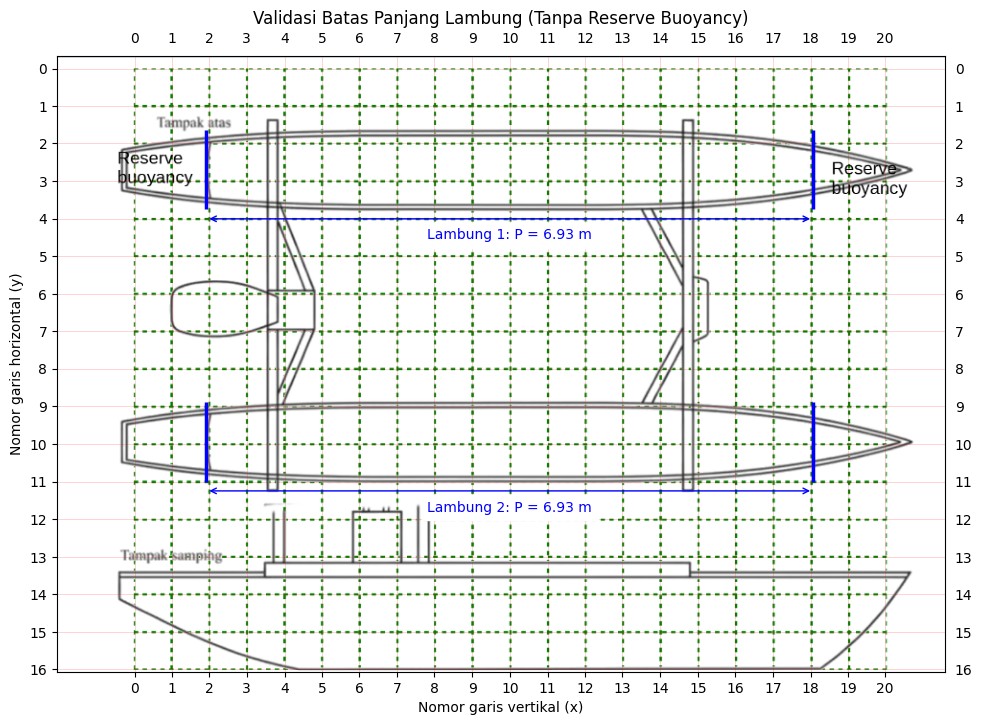

In [6]:
# Piksel gelap = garis gambar kapal (abu-abu/hitam), bukan garis hijau grid atau teks berwarna
gelap = (
    (data.max(axis=2) < 170) &
    (np.abs(R - G) < 30) &
    (np.abs(G - B) < 30)
)

# Perkiraan awal posisi batas reserve buoyancy (nomor garis grid, dari pengamatan plot Step 2)
grid_kiri_perkiraan = 2
grid_kanan_perkiraan = 18

# Daerah baris (sumbu y) tempat tiap lambung berada, dinyatakan dengan nomor garis horizontal
daerah_lambung = {
    "Lambung 1": (garis_horizontal[1], garis_horizontal[4]),
    "Lambung 2": (garis_horizontal[8], garis_horizontal[12]),
}

# Pertengahan badan lambung (garis x ke-10) dipakai untuk mencari tepi atas dan bawah lambung
x_tengah_badan = int(round(garis_vertikal[10]))


# Posisi tengah lambung pada sumbu y: titik tengah antara tepi atas dan tepi bawah
def cari_y_tengah(y_atas, y_bawah):
    y_atas, y_bawah = int(round(y_atas)), int(round(y_bawah))
    ys = np.where(gelap[y_atas:y_bawah, x_tengah_badan])[0] + y_atas
    return ys.min(), ys.max(), (ys.min() + ys.max()) / 2


# Mencari posisi garis batas reserve buoyancy di sekitar nomor garis perkiraan
def cari_batas(y_tengah, grid_perkiraan):
    x_perkiraan = garis_vertikal[grid_perkiraan]
    x_min = int(round(x_perkiraan - 0.5 * pixel_per_kotak_x))
    x_max = int(round(x_perkiraan + 0.5 * pixel_per_kotak_x))
    y = int(round(y_tengah))

    profil = gelap[y - 2:y + 3, x_min:x_max].any(axis=0)
    x_gelap = np.where(profil)[0] + x_min
    garis = kelompokkan_garis(x_gelap)

    # Ambil garis yang paling dekat dengan nomor garis perkiraan
    return garis[np.argmin(np.abs(garis - x_perkiraan))]


hasil_panjang = {}

for nama, (y_atas, y_bawah) in daerah_lambung.items():
    y_min, y_max, y_tengah = cari_y_tengah(y_atas, y_bawah)
    x_awal = cari_batas(y_tengah, grid_kiri_perkiraan)
    x_akhir = cari_batas(y_tengah, grid_kanan_perkiraan)

    panjang_px = x_akhir - x_awal
    panjang_m = panjang_px * meter_per_pixel

    hasil_panjang[nama] = dict(y_min=y_min, y_max=y_max, x_awal=x_awal, x_akhir=x_akhir, panjang_m=panjang_m)

    print(f"{nama}")
    print(f"  Batas kiri  : x = {x_awal:.1f} px  (garis grid ke-{(x_awal - garis_vertikal[0]) / pixel_per_kotak_x:.2f})")
    print(f"  Batas kanan : x = {x_akhir:.1f} px  (garis grid ke-{(x_akhir - garis_vertikal[0]) / pixel_per_kotak_x:.2f})")
    print(f"  Panjang     : {panjang_px:.1f} px = {panjang_px / pixel_per_kotak_x:.2f} kotak = {panjang_m:.3f} m")

# Panjang lambung yang dipakai: rata-rata kedua lambung
panjang_lambung = np.mean([h["panjang_m"] for h in hasil_panjang.values()])
x_awal_lambung = np.mean([h["x_awal"] for h in hasil_panjang.values()])
x_akhir_lambung = np.mean([h["x_akhir"] for h in hasil_panjang.values()])

print(f"\nPanjang lambung (tanpa reserve buoyancy) : {panjang_lambung:.3f} m")


# Validasi: batas panjang lambung digambar di atas gambar asli
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(gambar)

for x in garis_vertikal:
    ax.axvline(x, color="red", linewidth=0.4, alpha=0.3)
for y in garis_horizontal:
    ax.axhline(y, color="red", linewidth=0.4, alpha=0.3)

for nama, h in hasil_panjang.items():
    ax.vlines(h["x_awal"], h["y_min"], h["y_max"], color="blue", linewidth=2.5)
    ax.vlines(h["x_akhir"], h["y_min"], h["y_max"], color="blue", linewidth=2.5)
    ax.annotate(
        "", xy=(h["x_akhir"], h["y_max"] + 0.25 * pixel_per_kotak_y),
        xytext=(h["x_awal"], h["y_max"] + 0.25 * pixel_per_kotak_y),
        arrowprops=dict(arrowstyle="<->", color="blue"),
    )
    ax.text(
        (h["x_awal"] + h["x_akhir"]) / 2, h["y_max"] + 0.5 * pixel_per_kotak_y,
        f"{nama}: P = {h['panjang_m']:.2f} m", ha="center", va="top",
        color="blue", fontsize=10, backgroundcolor="white",
    )

ax.set_xticks(garis_vertikal)
ax.set_xticklabels(range(len(garis_vertikal)))
ax.set_yticks(garis_horizontal)
ax.set_yticklabels(range(len(garis_horizontal)))
ax.tick_params(labeltop=True, labelright=True)
ax.set_xlabel("Nomor garis vertikal (x)")
ax.set_ylabel("Nomor garis horizontal (y)")
ax.set_title("Validasi Batas Panjang Lambung (Tanpa Reserve Buoyancy)")
plt.show()

### Interpretasi

Garis batas *reserve buoyancy* ditemukan sangat dekat dengan garis grid ke-2 (kiri) dan ke-18 (kanan). Posisi pastinya sekitar garis grid ke-1,9 sampai 2,0 untuk batas kiri dan ke-18,0 sampai 18,2 untuk batas kanan. Jarak keduanya sekitar **16,1 sampai 16,2 kotak**.

Dengan skala dari Step 2 (1 dash-kosong = 0,1 m), panjang lambung tanpa *reserve buoyancy* diperoleh sekitar **6,9 m**. Sebagai pengecekan, 16 kotak × 0,43 m ≈ 6,85 m, sehingga selisihnya kurang dari 1%.

Kedua lambung memiliki panjang yang sama, sesuai dengan gambar yang memperlihatkan dua lambung identik. Nilai `panjang_lambung`, `x_awal_lambung`, dan `x_akhir_lambung` akan dipakai pada langkah berikutnya untuk mengukur lebar dan tinggi lambung di sepanjang badan kapal.

## 4. Menghitung Lebar Lambung

Pada tampak atas, lambung **meruncing** di kedua ujungnya, sehingga lebarnya tidak konstan di sepanjang badan kapal. Karena itu lebar diukur sebagai fungsi posisi, $w(x)$, bukan satu angka tunggal.

Langkah yang dilakukan:
1. Untuk setiap kolom piksel di antara batas kiri dan kanan lambung (hasil Step 3), telusuri dari titik tengah lambung ke arah atas dan bawah sampai tepi luar dinding lambung. Dinding lambung digambar sebagai garis ganda, sehingga celah yang sangat kecil dianggap masih satu dinding.
2. Hitung lebar = jarak tepi bawah − tepi atas, lalu ubah ke meter dengan skala dari Step 2.
3. Kolom yang terganggu batang penghubung atau penyangga dideteksi karena lebarnya menyimpang dari nilai di sekitarnya, lalu diganti dengan interpolasi.
4. Memvalidasi hasilnya dengan menggambarkan tepi lambung di atas gambar dan membuat grafik profil lebar.

Jumlah kolom pengganggu : lambung 1 = 63, lambung 2 = 56 dari 633 kolom
Lebar maksimum lambung 1 : 0.930 m
Lebar maksimum lambung 2 : 0.919 m
Lebar rata-rata lambung 1 : 0.871 m
Lebar rata-rata lambung 2 : 0.869 m


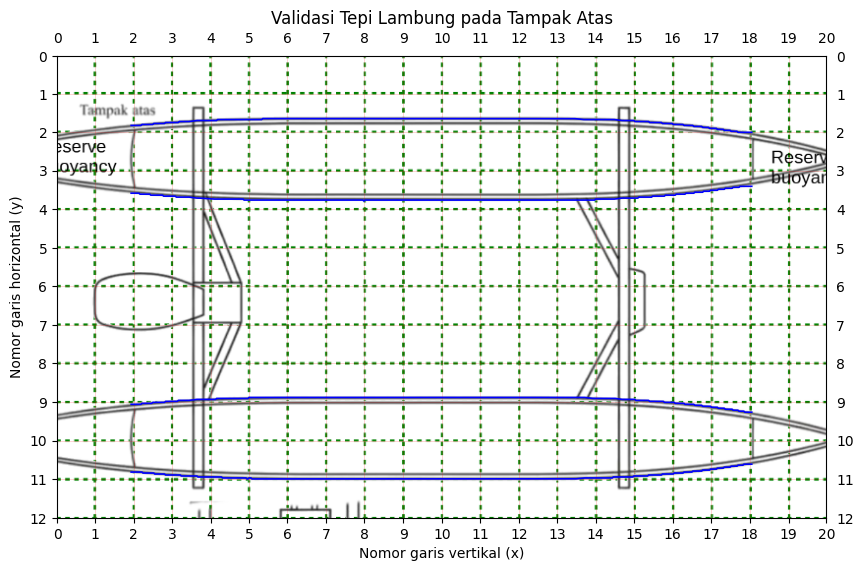

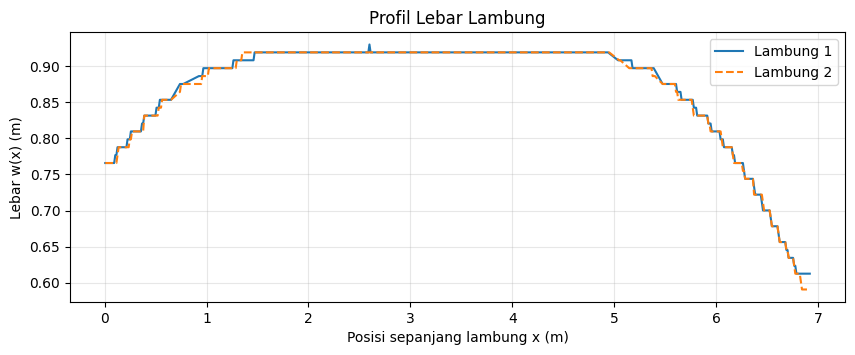

In [7]:
from scipy.ndimage import median_filter

# Garis tepi lambung digambar ganda (garis luar dan garis dalam) dengan celah sangat kecil.
# Celah di bawah batas ini dianggap masih satu dinding lambung.
celah_dinding_m = 0.04
celah_dinding_px = max(2, int(round(celah_dinding_m * pixel_per_meter)))

# Posisi kolom piksel di sepanjang lambung (dari batas kiri sampai batas kanan)
x_px = np.arange(int(round(x_awal_lambung)), int(round(x_akhir_lambung)) + 1)
x_m = (x_px - x_awal_lambung) * meter_per_pixel      # posisi sepanjang lambung (m)


# Dari titik tengah lambung, telusuri ke arah luar sampai tepi luar dinding lambung
def tepi_luar(kolom, y_tengah, arah):
    if arah == "atas":
        ys = np.where(kolom[:int(y_tengah)])[0][::-1]     # dari tengah menuju atas
    else:
        ys = np.where(kolom[int(y_tengah):])[0] + int(y_tengah)   # dari tengah menuju bawah

    if len(ys) == 0:
        return np.nan

    tepi = ys[0]
    for y in ys[1:]:
        if abs(y - tepi) - 1 <= celah_dinding_px:
            tepi = y
        else:
            break
    return tepi


# Mengukur tepi atas, tepi bawah, dan lebar lambung pada setiap kolom
def ukur_lebar(nama):
    h = hasil_panjang[nama]
    y_atas, y_bawah = daerah_lambung[nama]
    y_atas, y_bawah = int(round(y_atas)), int(round(y_bawah))
    y_tengah = (h["y_min"] + h["y_max"]) / 2 - y_atas

    atas = np.full(len(x_px), np.nan)
    bawah = np.full(len(x_px), np.nan)

    for i, x in enumerate(x_px):
        kolom = gelap[y_atas:y_bawah, x]
        atas[i] = tepi_luar(kolom, y_tengah, "atas") + y_atas
        bawah[i] = tepi_luar(kolom, y_tengah, "bawah") + y_atas

    lebar_px = bawah - atas + 1

    # Kolom yang terganggu batang penghubung/penyangga: lebarnya menyimpang dari nilai sekitarnya
    lebar_isi = np.where(np.isnan(lebar_px), np.nanmedian(lebar_px), lebar_px)
    jendela = int(round(0.6 * pixel_per_meter)) // 2 * 2 + 1
    median_lokal = median_filter(lebar_isi, size=jendela, mode="reflect")
    ambang = max(2, 0.015 * pixel_per_meter)
    pengganggu = np.isnan(lebar_px) | (np.abs(lebar_isi - median_lokal) > ambang)
    pengganggu = np.convolve(pengganggu, np.ones(5), mode="same") > 0

    # Kolom pengganggu diganti dengan interpolasi dari kolom di kiri-kanannya
    lebar_bersih = np.interp(x_px, x_px[~pengganggu], lebar_px[~pengganggu])
    atas_bersih = np.interp(x_px, x_px[~pengganggu], atas[~pengganggu])

    return atas_bersih, atas_bersih + lebar_bersih - 1, lebar_bersih * meter_per_pixel, pengganggu


atas_1, bawah_1, lebar_1, pengganggu_1 = ukur_lebar("Lambung 1")
atas_2, bawah_2, lebar_2, pengganggu_2 = ukur_lebar("Lambung 2")

print(f"Jumlah kolom pengganggu : lambung 1 = {pengganggu_1.sum()}, lambung 2 = {pengganggu_2.sum()} dari {len(x_px)} kolom")
print(f"Lebar maksimum lambung 1 : {lebar_1.max():.3f} m")
print(f"Lebar maksimum lambung 2 : {lebar_2.max():.3f} m")
print(f"Lebar rata-rata lambung 1 : {lebar_1.mean():.3f} m")
print(f"Lebar rata-rata lambung 2 : {lebar_2.mean():.3f} m")


# Validasi 1: tepi atas dan bawah lambung digambar di atas gambar asli
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(gambar)

for x in garis_vertikal:
    ax.axvline(x, color="red", linewidth=0.4, alpha=0.3)
for y in garis_horizontal:
    ax.axhline(y, color="red", linewidth=0.4, alpha=0.3)

for atas, bawah in [(atas_1, bawah_1), (atas_2, bawah_2)]:
    ax.plot(x_px, atas, color="blue", linewidth=1.2)
    ax.plot(x_px, bawah, color="blue", linewidth=1.2)

ax.set_xticks(garis_vertikal)
ax.set_xticklabels(range(len(garis_vertikal)))
ax.set_yticks(garis_horizontal)
ax.set_yticklabels(range(len(garis_horizontal)))
ax.tick_params(labeltop=True, labelright=True)
ax.set_xlim(garis_vertikal[0], garis_vertikal[-1])
ax.set_ylim(garis_horizontal[12], garis_horizontal[0])
ax.set_xlabel("Nomor garis vertikal (x)")
ax.set_ylabel("Nomor garis horizontal (y)")
ax.set_title("Validasi Tepi Lambung pada Tampak Atas")
plt.show()

# Validasi 2: profil lebar lambung sepanjang badan kapal
plt.figure(figsize=(10, 3.5))
plt.plot(x_m, lebar_1, label="Lambung 1")
plt.plot(x_m, lebar_2, "--", label="Lambung 2")
plt.xlabel("Posisi sepanjang lambung x (m)")
plt.ylabel("Lebar w(x) (m)")
plt.title("Profil Lebar Lambung")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretasi

Lebar lambung diukur dari tepi luar dinding lambung pada tampak atas. Lebar maksimum kedua lambung sekitar **0,92 m** dan tercapai di bagian tengah badan kapal. Dari tengah ke arah haluan dan buritan, lebarnya mengecil secara bertahap karena lambung meruncing. Pengecilan ini lebih tajam di sisi haluan (kanan) daripada di sisi buritan (kiri).

Beberapa kolom terganggu oleh batang penghubung dan penyangga yang menempel pada lambung, sehingga lebarnya tampak menyimpang. Kolom-kolom tersebut dideteksi dan diganti dengan interpolasi, dan hasilnya terlihat pada grafik profil yang halus tanpa lonjakan.

Lebar rata-rata kedua lambung sekitar **0,87 m**, lebih kecil dari lebar maksimumnya. Karena itu, mengalikan panjang dengan lebar maksimum akan melebih-lebihkan volume. Profil $w(x)$ inilah yang dipakai pada integrasi numerik di langkah berikutnya, bersama profil tinggi $h(x)$ dari tampak samping.

## 5. Menghitung Tinggi Lambung

Tinggi lambung diukur dari **tampak samping**. Karena lantai kapal dianggap datar (tanpa keel), tampak depan lambung berbentuk persegi panjang, sehingga pada setiap posisi $x$ luas penampang lambung adalah lebar × tinggi, yaitu $w(x) \cdot h(x)$. Tinggi $h(x)$ diukur dari garis dek (tepi atas lambung) sampai lengkung dasar lambung.

Langkah yang dilakukan:
1. Menentukan daerah tampak samping, yaitu sekitar garis horizontal ke-13 sampai ke-16.
2. Menentukan posisi garis dek ($y_{dek}$) pada kolom di dekat haluan (garis vertikal ke-17), yang bebas dari kabin dan tiang di atas dek.
3. Untuk setiap kolom piksel di antara batas kiri dan kanan lambung (hasil Step 3), cari piksel gelap paling bawah. Piksel ini adalah dasar lambung.
4. Menghitung tinggi:

$$
h(x) = (y_{dasar} - y_{dek} + 1) \times \text{meter per piksel}
$$

5. Kolom yang garisnya tertutup garis hijau grid dideteksi karena tingginya menyimpang dari nilai di sekitarnya, lalu diganti dengan interpolasi.
6. Memvalidasi hasilnya dengan menggambarkan dasar lambung di atas gambar dan membuat grafik profil tinggi.

Garis dek                : y = 538 px
Kolom pengganggu         : 10 dari 633 kolom
Tinggi di batas kiri     : 0.864 m
Tinggi di batas kanan    : 1.127 m
Tinggi maksimum          : 1.127 m
Tinggi rata-rata         : 1.107 m


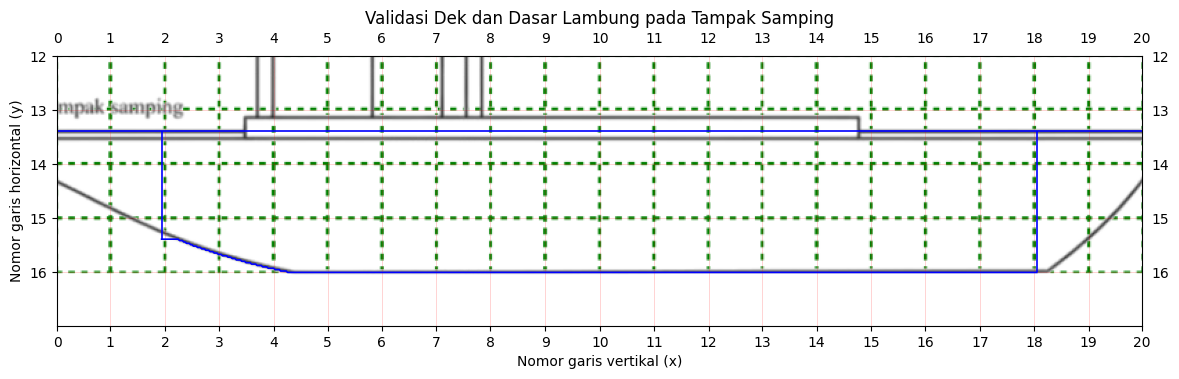

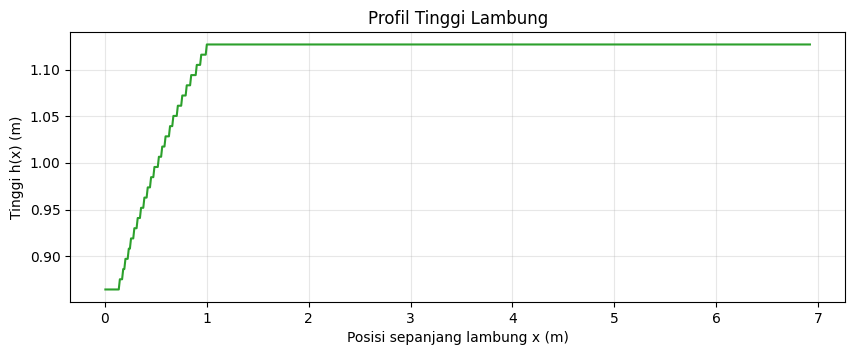

In [10]:
# Daerah tampak samping (baris y): dari garis horizontal ke-13 sampai sedikit di bawah garis ke-16
y_awal_samping = int(round(garis_horizontal[13]))
y_akhir_samping = int(round(garis_horizontal[16] + 0.3 * pixel_per_kotak_y))

# Garis dek: piksel gelap paling atas pada kolom garis vertikal ke-17
# (kolom ini di sebelah kanan kabin dan tiang, jadi hanya berisi garis dek dan dasar lambung)
x_acuan_dek = int(round(garis_vertikal[17]))
ys_acuan = np.where(gelap[y_awal_samping:y_akhir_samping, x_acuan_dek])[0] + y_awal_samping
y_dek = ys_acuan.min()

# Dasar lambung: piksel gelap paling bawah pada setiap kolom, di bawah garis dek
y_dasar = np.full(len(x_px), np.nan)

for i, x in enumerate(x_px):
    ys = np.where(gelap[y_dek:y_akhir_samping, x])[0]
    if len(ys) > 0:
        y_dasar[i] = ys.max() + y_dek

tinggi_px = y_dasar - y_dek + 1

# Kolom pengganggu (garis tertutup grid hijau): tinggi menyimpang dari median lokal
tinggi_isi = np.where(np.isnan(tinggi_px), np.nanmedian(tinggi_px), tinggi_px)
jendela = int(round(0.6 * pixel_per_meter)) // 2 * 2 + 1
median_lokal = median_filter(tinggi_isi, size=jendela, mode="reflect")
ambang = max(2, 0.015 * pixel_per_meter)
pengganggu_h = np.isnan(tinggi_px) | (np.abs(tinggi_isi - median_lokal) > ambang)
pengganggu_h = np.convolve(pengganggu_h, np.ones(5), mode="same") > 0

# Kolom pengganggu diganti interpolasi dari kolom di kiri-kanannya
tinggi_bersih = np.interp(x_px, x_px[~pengganggu_h], tinggi_px[~pengganggu_h])
y_dasar_bersih = y_dek + tinggi_bersih - 1
tinggi_m = tinggi_bersih * meter_per_pixel

print(f"Garis dek                : y = {y_dek} px")
print(f"Kolom pengganggu         : {pengganggu_h.sum()} dari {len(x_px)} kolom")
print(f"Tinggi di batas kiri     : {tinggi_m[0]:.3f} m")
print(f"Tinggi di batas kanan    : {tinggi_m[-1]:.3f} m")
print(f"Tinggi maksimum          : {tinggi_m.max():.3f} m")
print(f"Tinggi rata-rata         : {tinggi_m.mean():.3f} m")


# Validasi 1: garis dek dan dasar lambung digambar di atas gambar asli
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(gambar)

for x in garis_vertikal:
    ax.axvline(x, color="red", linewidth=0.4, alpha=0.3)
for y in garis_horizontal:
    ax.axhline(y, color="red", linewidth=0.4, alpha=0.3)

ax.axhline(y_dek, color="blue", linewidth=1.2)
ax.plot(x_px, y_dasar_bersih, color="blue", linewidth=1.2)
ax.vlines([x_px[0], x_px[-1]], y_dek, [y_dasar_bersih[0], y_dasar_bersih[-1]],
          color="blue", linewidth=1.2)

ax.set_xticks(garis_vertikal)
ax.set_xticklabels(range(len(garis_vertikal)))
ax.set_yticks(garis_horizontal)
ax.set_yticklabels(range(len(garis_horizontal)))
ax.tick_params(labeltop=True, labelright=True)
ax.set_xlim(garis_vertikal[0], garis_vertikal[-1])
ax.set_ylim(garis_horizontal[16] + pixel_per_kotak_y, garis_horizontal[12])
ax.set_xlabel("Nomor garis vertikal (x)")
ax.set_ylabel("Nomor garis horizontal (y)")
ax.set_title("Validasi Dek dan Dasar Lambung pada Tampak Samping")
plt.show()

# Validasi 2: profil tinggi lambung sepanjang badan kapal
plt.figure(figsize=(10, 3.5))
plt.plot(x_m, tinggi_m, color="tab:green")
plt.xlabel("Posisi sepanjang lambung x (m)")
plt.ylabel("Tinggi h(x) (m)")
plt.title("Profil Tinggi Lambung")
plt.grid(alpha=0.3)
plt.show()

### Interpretasi

Tinggi lambung diukur dari garis dek sampai lengkung dasar lambung pada tampak samping. Di batas kiri (buritan) tingginya sekitar **0,8 m**, lalu bertambah secara bertahap mengikuti lengkung dasar sampai sekitar **1,1 m**. Setelah itu dasar lambung datar sampai batas kanan, sehingga tingginya hampir konstan.

Sebagian kolom garis dasarnya tertutup garis hijau grid, sehingga tingginya tampak menyimpang. Kolom-kolom tersebut dideteksi dan diganti dengan interpolasi, dan hasilnya terlihat pada grafik profil yang halus tanpa lonjakan.

Karena lantai kapal dianggap datar, tampak depan lambung berbentuk persegi panjang, sehingga luas penampang pada posisi $x$ adalah $A(x) = w(x) \cdot h(x)$. Profil $h(x)$ ini dipakai bersama profil lebar $w(x)$ dari Step 4 pada integrasi numerik di langkah berikutnya.

## 6. Menghitung Volume Kedua Lambung

Karena lantai kapal dianggap datar, tampak depan lambung berbentuk persegi panjang, sehingga luas penampang pada posisi $x$ adalah

$$
A(x) = w(x) \cdot h(x)
$$

dan volume satu lambung adalah integral luas penampang sepanjang lambung:

$$
V = \int_{0}^{P} w(x)\, h(x)\, dx
$$

Karena $w(x)$ dan $h(x)$ berupa data diskrit (satu nilai per kolom piksel), integral dihitung secara numerik. Jarak antar-kolom adalah $\Delta x$ = meter per piksel.

Langkah yang dilakukan:
1. Menghitung $A(x) = w(x) \cdot h(x)$ untuk setiap lambung. Profil $h(x)$ sama untuk kedua lambung, sedangkan $w(x)$ diukur terpisah.
2. Mengintegralkan $A(x)$ dengan tiga metode: **jumlah Riemann (kiri)**, **aturan trapesium**, dan **aturan Simpson**.
3. Membandingkan ketiga hasilnya untuk memastikan hasil integrasi stabil.
4. Menjumlahkan volume kedua lambung dan mengecek hasilnya dengan perkiraan kasar $P \times \bar{w} \times \bar{h}$.
5. Memvalidasi dengan grafik luas penampang $A(x)$.

                Riemann (m3)    Trapesium (m3)    Simpson (m3)
Lambung 1             6.6745            6.6747          6.6747
Lambung 2             6.6667            6.6667          6.6668

Volume lambung 1 : 6.675 m3  (6675 liter)
Volume lambung 2 : 6.667 m3  (6667 liter)
Volume total     : 13.342 m3  (13342 liter)
Perkiraan kasar Lambung 1 (P x w_rata2 x h_rata2) : 6.674 m3
Perkiraan kasar Lambung 2 (P x w_rata2 x h_rata2) : 6.666 m3


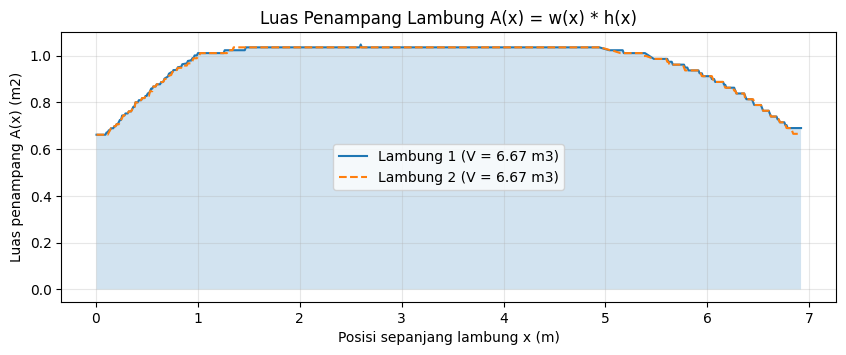

In [11]:
from scipy.integrate import simpson, trapezoid

dx = meter_per_pixel            # jarak antar-kolom piksel (m)

# Luas penampang A(x) = w(x) * h(x) untuk tiap lambung
A_1 = lebar_1 * tinggi_m
A_2 = lebar_2 * tinggi_m


# Tiga metode integrasi numerik
def volume_riemann(A):
    return np.sum(A[:-1]) * dx

def volume_trapesium(A):
    return trapezoid(A, dx=dx)

def volume_simpson(A):
    return simpson(A, dx=dx)


hasil_volume = {}
for nama, A in [("Lambung 1", A_1), ("Lambung 2", A_2)]:
    hasil_volume[nama] = dict(
        riemann=volume_riemann(A),
        trapesium=volume_trapesium(A),
        simpson=volume_simpson(A),
    )

print(f"{'':12s}{'Riemann (m3)':>16s}{'Trapesium (m3)':>18s}{'Simpson (m3)':>16s}")
for nama, v in hasil_volume.items():
    print(f"{nama:12s}{v['riemann']:16.4f}{v['trapesium']:18.4f}{v['simpson']:16.4f}")

# Volume yang dipakai: metode Simpson
volume_1 = hasil_volume["Lambung 1"]["simpson"]
volume_2 = hasil_volume["Lambung 2"]["simpson"]
volume_total = volume_1 + volume_2

print(f"\nVolume lambung 1 : {volume_1:.3f} m3  ({volume_1 * 1000:.0f} liter)")
print(f"Volume lambung 2 : {volume_2:.3f} m3  ({volume_2 * 1000:.0f} liter)")
print(f"Volume total     : {volume_total:.3f} m3  ({volume_total * 1000:.0f} liter)")

# Pengecekan kasar: panjang x lebar rata-rata x tinggi rata-rata
for nama, lebar in [("Lambung 1", lebar_1), ("Lambung 2", lebar_2)]:
    kasar = panjang_lambung * lebar.mean() * tinggi_m.mean()
    print(f"Perkiraan kasar {nama} (P x w_rata2 x h_rata2) : {kasar:.3f} m3")


# Validasi: grafik luas penampang sepanjang lambung
plt.figure(figsize=(10, 3.5))
plt.plot(x_m, A_1, label=f"Lambung 1 (V = {volume_1:.2f} m3)")
plt.plot(x_m, A_2, "--", label=f"Lambung 2 (V = {volume_2:.2f} m3)")
plt.fill_between(x_m, A_1, alpha=0.2)
plt.xlabel("Posisi sepanjang lambung x (m)")
plt.ylabel("Luas penampang A(x) (m2)")
plt.title("Luas Penampang Lambung A(x) = w(x) * h(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretasi

Volume tiap lambung dihitung dengan mengintegralkan luas penampang $A(x) = w(x) \cdot h(x)$ sepanjang lambung. Ketiga metode (Riemann, trapesium, Simpson) memberi hasil yang hampir sama, dengan selisih jauh di bawah 1%. Ini menunjukkan integrasi sudah stabil karena datanya rapat (satu nilai per kolom piksel) dan profilnya mulus.

Volume satu lambung sekitar **6,7 m³**, sehingga volume **kedua lambung sekitar 13,5 m³** (sekitar 13.500 liter). Kedua lambung hampir sama karena gambarnya memperlihatkan dua lambung identik. Selisih kecil di antara keduanya berasal dari perbedaan hasil pengukuran lebar pada tampak atas.

Sebagai pengecekan, perkiraan kasar $P \times \bar{w} \times \bar{h}$ memberi nilai yang dekat dengan hasil integrasi. Grafik $A(x)$ memperlihatkan luas penampang kecil di ujung kiri, naik cepat sampai sekitar bagian tengah, lalu mengecil lagi ke ujung kanan karena lambung meruncing. Karena itu, integrasi $w(x) \cdot h(x)$ lebih akurat daripada mengalikan panjang, lebar maksimum, dan tinggi maksimum, yang akan melebih-lebihkan volume.

## 7. Rekap Hasil dan Kesimpulan

Langkah terakhir adalah merangkum seluruh hasil pengukuran dari Step 2 sampai Step 6 dalam satu tabel, lalu menarik kesimpulan.

Langkah yang dilakukan:
1. Mengumpulkan skala gambar, panjang, lebar, tinggi, dan volume tiap lambung.
2. Menampilkan hasilnya dalam satu tabel rekap.
3. Menuliskan kesimpulan berdasarkan tabel tersebut.

In [12]:
import pandas as pd

rekap = pd.DataFrame({
    "Besaran": [
        "Skala gambar (px/m)",
        "Panjang lambung tanpa reserve buoyancy (m)",
        "Lebar maksimum (m)",
        "Lebar rata-rata (m)",
        "Tinggi maksimum (m)",
        "Tinggi rata-rata (m)",
        "Volume, metode Simpson (m3)",
    ],
    "Lambung 1": [
        f"{pixel_per_meter:.2f}",
        f"{hasil_panjang['Lambung 1']['panjang_m']:.3f}",
        f"{lebar_1.max():.3f}",
        f"{lebar_1.mean():.3f}",
        f"{tinggi_m.max():.3f}",
        f"{tinggi_m.mean():.3f}",
        f"{volume_1:.3f}",
    ],
    "Lambung 2": [
        f"{pixel_per_meter:.2f}",
        f"{hasil_panjang['Lambung 2']['panjang_m']:.3f}",
        f"{lebar_2.max():.3f}",
        f"{lebar_2.mean():.3f}",
        f"{tinggi_m.max():.3f}",
        f"{tinggi_m.mean():.3f}",
        f"{volume_2:.3f}",
    ],
})

display(rekap.style.hide(axis="index"))

print(f"\nVolume kedua lambung = {volume_1:.3f} + {volume_2:.3f} = {volume_total:.3f} m3 "
      f"({volume_total * 1000:.0f} liter)")

Besaran,Lambung 1,Lambung 2
Skala gambar (px/m),91.40,91.40
Panjang lambung tanpa reserve buoyancy (m),6.925,6.925
Lebar maksimum (m),0.930,0.919
Lebar rata-rata (m),0.871,0.869
Tinggi maksimum (m),1.127,1.127
Tinggi rata-rata (m),1.107,1.107
"Volume, metode Simpson (m3)",6.675,6.667



Volume kedua lambung = 6.675 + 6.667 = 13.342 m3 (13342 liter)


### Kesimpulan

Volume kedua lambung kapal katamaran dihitung dari gambar tampak atas dan tampak samping dengan langkah berikut:

1. Skala gambar ditentukan dari panjang satu dash-kosong (5 + 5 cm = 0,1 m), sehingga diperoleh sekitar **83 piksel per meter** (nilai pastinya bergantung pada resolusi `perahu_page1.png`). Satu kotak grid ternyata sekitar 0,43 m, bukan 0,1 m.
2. Panjang lambung tanpa *reserve buoyancy* diukur di antara kedua sekat, yaitu sekitar **6,9 m**.
3. Lebar $w(x)$ diukur per kolom piksel pada tampak atas. Lebar maksimumnya sekitar **0,92 m** dan lebar rata-ratanya sekitar **0,87 m**.
4. Tinggi $h(x)$ diukur per kolom piksel pada tampak samping, dari garis dek sampai dasar lambung. Tingginya naik dari sekitar 0,8 m di buritan sampai sekitar **1,1 m**, lalu hampir konstan.
5. Karena lantai kapal dianggap datar, tampak depan lambung berbentuk persegi panjang, sehingga luas penampang $A(x) = w(x) \cdot h(x)$ dan volumenya dihitung dengan integrasi numerik $V = \int w(x)\,h(x)\,dx$.

Hasilnya, volume satu lambung sekitar **6,7 m³**, sehingga volume **kedua lambung sekitar 13,5 m³** (sekitar 13.500 liter). Metode Riemann, trapesium, dan Simpson memberi hasil yang hampir sama, jadi hasil integrasinya stabil.

Beberapa catatan tentang hasil ini:
- Volume *reserve buoyancy* di kedua ujung lambung tidak dihitung, sesuai ketentuan soal.
- Tinggi dan lebar diukur dari tepi luar garis gambar, sehingga ketebalan dinding tidak dikurangkan.
- Pengukuran berasal dari gambar piksel, sehingga ada ketidakpastian sekitar satu atau dua piksel pada tepi lambung dan sedikit pengaruh dari garis hijau grid yang menutupi garis gambar.
- Hasil ini jauh lebih besar daripada perhitungan awal dengan metode kotak (0,288 m³), karena perhitungan awal menganggap satu kotak grid = 10 cm, padahal satu kotak grid sekitar 0,43 m.